# Structural Break Detection

**Docker image**: `ml4t`

This notebook demonstrates classical and ML-based methods for detecting
structural breaks in financial time series.

**Learning Objectives**:
- Apply Zivot-Andrews and Bai-Perron tests for structural break detection
- Implement CUSUM and MOSUM monitoring statistics for online break detection
- Frame break detection as binary classification (ADIA Lab approach)
- Build statistical features for break classification: location shift,
  scale shift, distribution shift, dependence shift
- Combine evidence across window sizes using Fisher aggregation

**Book Reference**: Chapter 9, Section 9.1 (Diagnostics and Stationarity Features)

**Prerequisites**: Complete `01_visual_diagnostics` for stationarity testing
fundamentals. Familiarity with hypothesis testing.

In [1]:
"""Structural Break Detection — classical tests and ML-based classification."""

import logging
import warnings
from typing import Any

warnings.filterwarnings("ignore")
# ml4t-engineer decorates some feature functions with per-call INFO timing logs
# (coefficient_of_variation sets log_data_quality=True), which otherwise leak
# into committed cell outputs as library chatter. Disable INFO so the outputs
# show only the feature values; WARNING and above still surface.
logging.disable(logging.INFO)

from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import ruptures as rpt
from arch.unitroot import ZivotAndrews
from IPython.display import display
from lightgbm import LGBMClassifier
from ml4t.engineer.features.statistics import (
    coefficient_of_variation,
    rolling_drift,
    rolling_kl_divergence,
    rolling_wasserstein,
)
from scipy import stats
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import cross_val_predict, cross_val_score

from data import load_etfs
from utils.reproducibility import set_global_seeds

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2000-01-01"
END_DATE = "2024-12-31"
SEED = 42

In [3]:
set_global_seeds(SEED)

## Load Data

We use SPY for demonstrating break detection on real financial data,
plus synthetic series for the ADIA Lab classification formulation.

In [4]:
etfs = load_etfs(symbols=["SPY"])

START = datetime.strptime(START_DATE, "%Y-%m-%d")
END = datetime.strptime(END_DATE, "%Y-%m-%d")

spy = (
    etfs.filter((pl.col("timestamp") >= START.date()) & (pl.col("timestamp") <= END.date()))
    .sort("timestamp")
    .select(["timestamp", "close"])
)

spy_pd = spy.to_pandas().set_index("timestamp")
spy_pd.index = pd.DatetimeIndex(spy_pd.index)
spy_pd["returns"] = np.log(spy_pd["close"]).diff() * 100

print(
    f"SPY: {len(spy_pd):,} observations ({spy_pd.index.min().date()} to {spy_pd.index.max().date()})"
)

SPY: 4,781 observations (2006-01-03 to 2024-12-31)


# Part 1 — Classical Structural Break Tests

These tests detect break points in level, trend, or volatility of a series.
The results produce features: `za_break_detected`, `days_since_break`,
`pre_break_mean`, `post_break_mean`.

### Zivot-Andrews Test

Tests for a unit root while allowing one endogenously determined structural
break. Unlike standard ADF, it doesn't assume constant data generation
throughout the sample.

In [5]:
def run_zivot_andrews(series: pd.Series, name: str) -> dict:
    """Run Zivot-Andrews test and return results with break location."""
    series = series.dropna()
    za = ZivotAndrews(series, lags=12, trend="ct", trim=0.15)

    return {
        "series": name,
        "za_stat": za.stat,
        "za_pval": za.pvalue,
        "critical_1pct": za.critical_values["1%"],
        "critical_5pct": za.critical_values["5%"],
        "reject_h0": za.pvalue < 0.05,
    }


za_result = run_zivot_andrews(spy_pd["close"], "SPY Levels")
print("=== Zivot-Andrews Test: SPY Levels ===")
print(f"Statistic: {za_result['za_stat']:.4f}")
print(f"P-value: {za_result['za_pval']:.4f}")
print(f"5% critical: {za_result['critical_5pct']:.4f}")
print(f"Reject H0: {za_result['reject_h0']}")

=== Zivot-Andrews Test: SPY Levels ===
Statistic: -3.3955
P-value: 0.8580
5% critical: -5.0733
Reject H0: False


### Bai-Perron: Multiple Break Points via `ruptures`

The Zivot-Andrews test finds at most one break. For multi-decade data,
multiple structural breaks are common (2008 crisis, COVID, etc.).
The `ruptures` library implements Bai-Perron style segmentation.

In [6]:
def detect_multiple_breaks(series: np.ndarray, n_breaks: int = 3, model: str = "l2") -> dict:
    """Detect multiple break points using Pelt or dynamic programming.

    Args:
        series: 1D array of values
        n_breaks: Expected number of breaks
        model: Cost model ('l2' for mean shift, 'rbf' for distribution shift)
    """
    # Pelt with penalty (automatic n_breaks)
    algo_pelt = rpt.Pelt(model=model, min_size=60).fit(series)
    breaks_pelt = algo_pelt.predict(pen=np.log(len(series)) * series.var())

    # Binary segmentation (fixed n_breaks)
    algo_binseg = rpt.Binseg(model=model, min_size=60).fit(series)
    breaks_binseg = algo_binseg.predict(n_bkps=n_breaks)

    return {
        "pelt_breaks": breaks_pelt[:-1],  # Remove last (=len)
        "binseg_breaks": breaks_binseg[:-1],
    }


prices = spy_pd["close"].dropna().values
breaks = detect_multiple_breaks(prices, n_breaks=4)

print(f"PELT breaks: {len(breaks['pelt_breaks'])} detected")
print(f"BinSeg breaks: {len(breaks['binseg_breaks'])} detected (requested 4)")

PELT breaks: 8 detected
BinSeg breaks: 4 detected (requested 4)


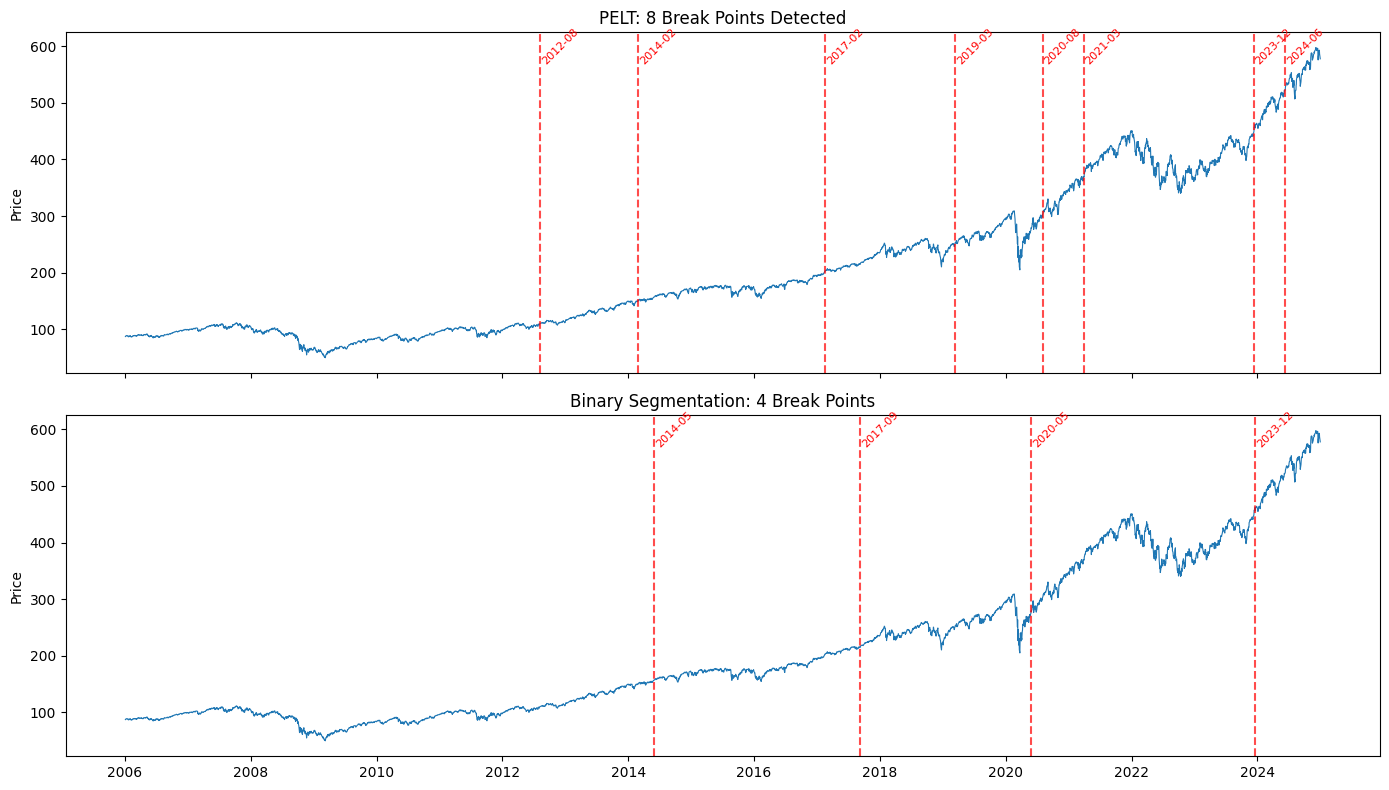

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

dates = spy_pd["close"].dropna().index

# PELT results
ax = axes[0]
ax.plot(dates, prices, linewidth=0.8)
for bp in breaks["pelt_breaks"]:
    if bp < len(dates):
        ax.axvline(dates[bp], color="red", linestyle="--", alpha=0.7)
        ax.text(
            dates[bp],
            prices.max() * 0.95,
            dates[bp].strftime("%Y-%m"),
            rotation=45,
            fontsize=8,
            color="red",
        )
ax.set_title(f"PELT: {len(breaks['pelt_breaks'])} Break Points Detected")
ax.set_ylabel("Price")

# BinSeg results
ax = axes[1]
ax.plot(dates, prices, linewidth=0.8)
for bp in breaks["binseg_breaks"]:
    if bp < len(dates):
        ax.axvline(dates[bp], color="red", linestyle="--", alpha=0.7)
        ax.text(
            dates[bp],
            prices.max() * 0.95,
            dates[bp].strftime("%Y-%m"),
            rotation=45,
            fontsize=8,
            color="red",
        )
ax.set_title("Binary Segmentation: 4 Break Points")
ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

### Break-Derived Features

Convert detected breaks into features usable by downstream ML models.

In [8]:
def compute_break_features(
    series: np.ndarray, breaks: list, dates: pd.DatetimeIndex
) -> pd.DataFrame:
    """Convert break points into time-varying features."""
    n = len(series)
    features = pd.DataFrame(index=dates[:n])

    # Binary: has a break been detected before this point?
    features["za_break_detected"] = 0
    for bp in breaks:
        if bp < n:
            features.iloc[bp:, features.columns.get_loc("za_break_detected")] = 1

    # Days since last break
    features["days_since_break"] = n  # Default: no break
    for i in range(n):
        past_breaks = [bp for bp in breaks if bp <= i]
        if past_breaks:
            features.iloc[i, features.columns.get_loc("days_since_break")] = i - max(past_breaks)

    # Pre/post break means (using most recent break)
    features["pre_break_mean"] = np.nan
    features["post_break_mean"] = np.nan
    for bp in sorted(breaks):
        if bp < n and bp > 50:
            pre_mean = series[max(0, bp - 252) : bp].mean()
            post_end = min(bp + 252, n)
            post_mean = series[bp:post_end].mean()
            features.iloc[bp:, features.columns.get_loc("pre_break_mean")] = pre_mean
            features.iloc[bp:, features.columns.get_loc("post_break_mean")] = post_mean

    return features


break_features = compute_break_features(prices, breaks["pelt_breaks"], dates)
display(break_features.dropna().head(10))

,za_break_detected,days_since_break,pre_break_mean,post_break_mean
timestamp,,,,
2012-08-06,1,0,100.718885,120.933755
2012-08-07,1,1,100.718885,120.933755
2012-08-08,1,2,100.718885,120.933755
2012-08-09,1,3,100.718885,120.933755
2012-08-10,1,4,100.718885,120.933755
2012-08-13,1,5,100.718885,120.933755
2012-08-14,1,6,100.718885,120.933755
2012-08-15,1,7,100.718885,120.933755
2012-08-16,1,8,100.718885,120.933755


### CUSUM Monitoring

The cumulative sum (CUSUM) statistic detects shifts in the mean of a process.
Unlike retrospective tests, CUSUM can be used for online monitoring —
it accumulates evidence sequentially and triggers when a threshold is exceeded.

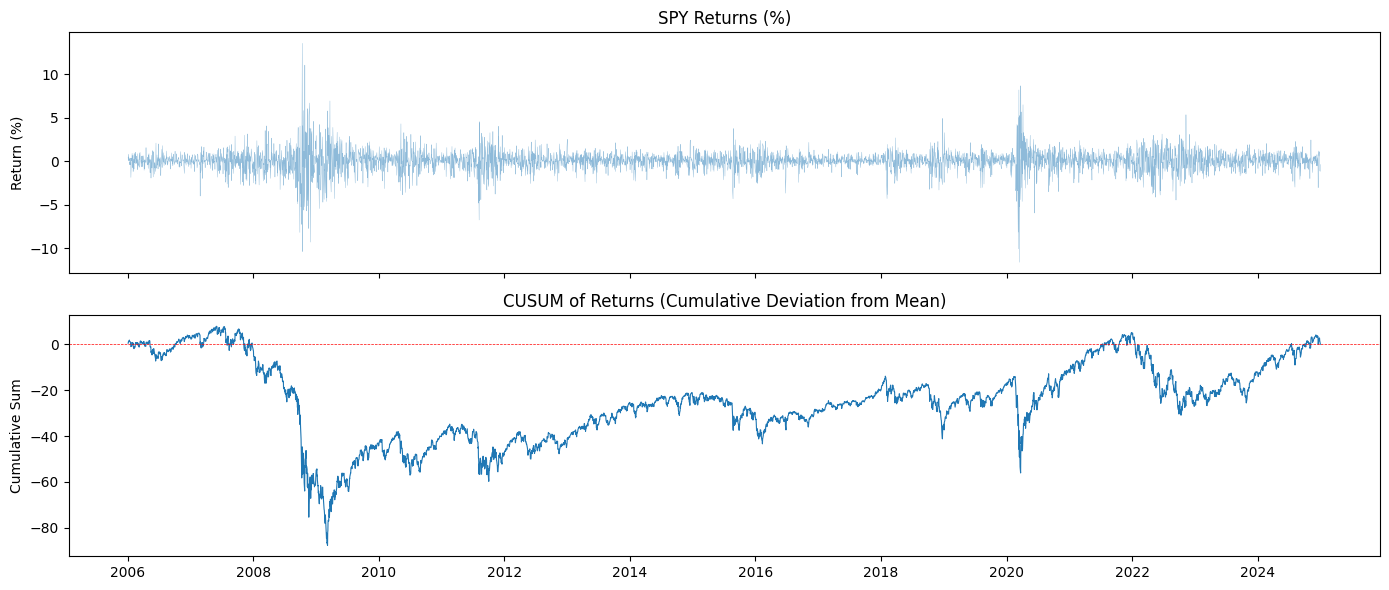

In [9]:
def cusum_statistic(series: np.ndarray, target: float | None = None) -> np.ndarray:
    """Compute one-sided CUSUM statistic.

    CUSUM accumulates deviations from the target mean.
    Sustained positive CUSUM indicates upward shift; negative indicates downward.
    """
    if target is None:
        target = series.mean()
    return np.cumsum(series - target)


returns = spy_pd["returns"].dropna()
cusum = cusum_statistic(returns.values)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(returns.index, returns.values, linewidth=0.3, alpha=0.5)
ax.set_title("SPY Returns (%)")
ax.set_ylabel("Return (%)")

ax = axes[1]
ax.plot(returns.index, cusum, linewidth=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("CUSUM of Returns (Cumulative Deviation from Mean)")
ax.set_ylabel("Cumulative Sum")

plt.tight_layout()
plt.show()

### MOSUM Monitoring

The moving sum (MOSUM) statistic complements CUSUM by using a **fixed-width
sliding window** rather than accumulating from the start. Where CUSUM detects
gradual drift, MOSUM is better at detecting abrupt, localized shifts — the
signal peaks at the break and decays as the window slides past.

The MOSUM at time $t$ with bandwidth $h$ is the standardized mean difference
between the observations in $[t-h, t]$ and the full-sample mean:

$$M_t = \frac{1}{\hat{\sigma}\sqrt{h}} \sum_{i=t-h+1}^{t} (x_i - \bar{x})$$

Large $|M_t|$ values indicate a local departure from the overall mean.

In [10]:
def mosum_statistic(
    series: np.ndarray, bandwidth: int = 50, target: float | None = None
) -> np.ndarray:
    """Compute MOSUM (moving sum) monitoring statistic.

    Unlike CUSUM which accumulates from the start, MOSUM uses a fixed-width
    sliding window — better at detecting abrupt, localized shifts.

    Parameters
    ----------
    series : array
        Input time series.
    bandwidth : int
        Window width (h). Larger h → smoother, less sensitive to short breaks.
    target : float, optional
        Reference mean. Defaults to full-sample mean.

    Returns
    -------
    mosum : array
        Standardized MOSUM statistic (same length as series, NaN-padded).
    """
    if target is None:
        target = series.mean()
    sigma = series.std()
    n = len(series)
    mosum = np.full(n, np.nan)
    for t in range(bandwidth, n):
        window_sum = np.sum(series[t - bandwidth + 1 : t + 1] - target)
        mosum[t] = window_sum / (sigma * np.sqrt(bandwidth))
    return mosum

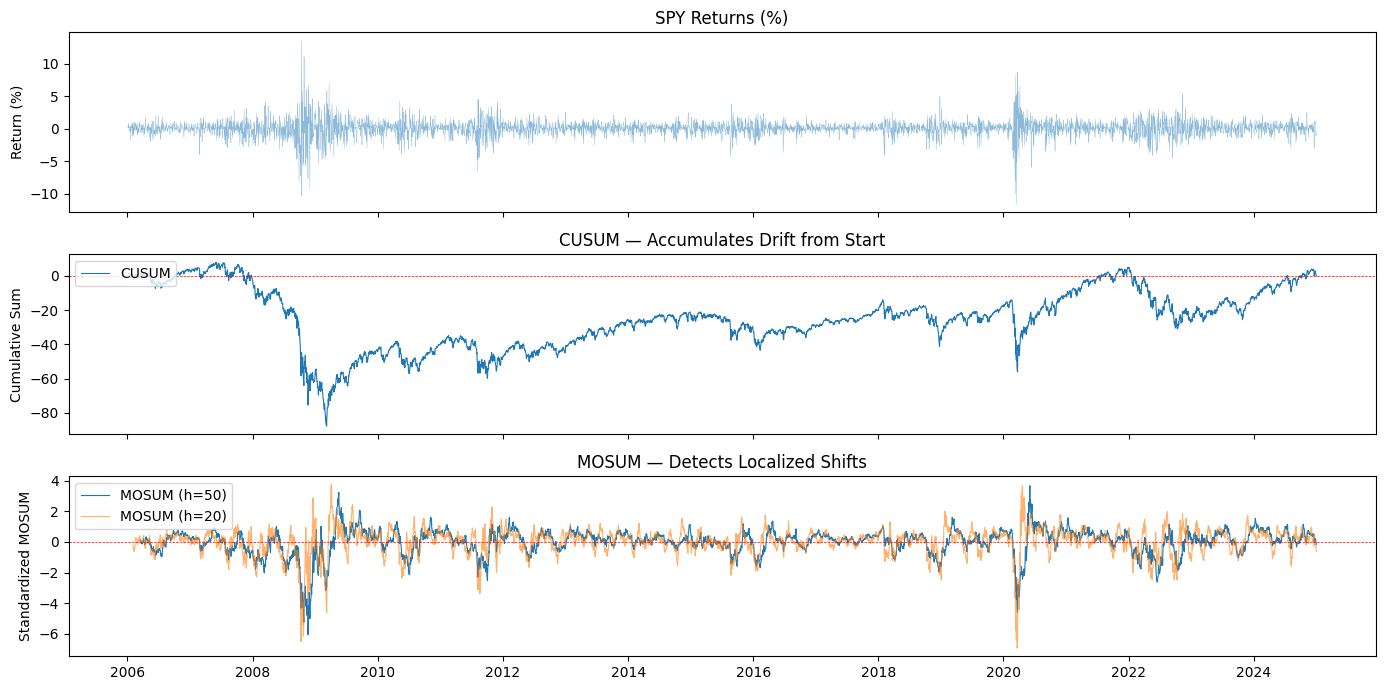

In [11]:
# Compare CUSUM and MOSUM on the same returns series
mosum_50 = mosum_statistic(returns.values, bandwidth=50)
mosum_20 = mosum_statistic(returns.values, bandwidth=20)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.plot(returns.index, returns.values, linewidth=0.3, alpha=0.5)
ax.set_title("SPY Returns (%)")
ax.set_ylabel("Return (%)")

ax = axes[1]
ax.plot(returns.index, cusum, linewidth=0.8, label="CUSUM")
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("CUSUM — Accumulates Drift from Start")
ax.set_ylabel("Cumulative Sum")
ax.legend(loc="upper left")

ax = axes[2]
ax.plot(returns.index, mosum_50, linewidth=0.8, label="MOSUM (h=50)")
ax.plot(returns.index, mosum_20, linewidth=0.8, alpha=0.6, label="MOSUM (h=20)")
ax.axhline(0, color="red", linestyle="--", linewidth=0.5)
ax.set_title("MOSUM — Detects Localized Shifts")
ax.set_ylabel("Standardized MOSUM")
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

**CUSUM vs MOSUM**: CUSUM is cumulative — once it detects a shift, the
statistic remains elevated permanently. MOSUM is local — it peaks at the
break and decays as the window slides past, making it easier to date breaks
precisely. The bandwidth $h$ controls sensitivity: smaller $h$ detects
shorter breaks but is noisier; larger $h$ is smoother but may miss brief
regime changes. Using both provides complementary evidence: CUSUM for
sustained drift, MOSUM for abrupt shifts.

# Part 2 — Break Detection as Binary Classification (ADIA Lab Formulation)

The ADIA Lab structural break competition reframes break detection as a
supervised classification problem: given a time series split at a candidate
boundary $\tau$, predict whether a structural break occurred at that point.

The Alphabot solution built 58 statistical features comparing the
pre-boundary and post-boundary windows. The construction combines
multiple tests, each probing a different aspect of distributional
change, into the features for a downstream classifier.

We implement the core feature families below. These features are useful
beyond competition — they provide a structured toolkit for detecting
regime changes in financial data.

### Generate Synthetic Data

Create training examples with known break structure for demonstration.

In [12]:
def generate_break_series(
    n: int = 500, break_type: str = "mean_shift", magnitude: float = 1.0, seed: int | None = None
) -> tuple[np.ndarray, bool, int]:
    """Generate a time series with or without a structural break at midpoint.

    Returns (series, has_break, break_idx).
    """
    rng = np.random.RandomState(seed)
    mid = n // 2

    if break_type == "none":
        series = rng.randn(n)
        return series, False, mid

    elif break_type == "mean_shift":
        pre = rng.randn(mid)
        post = rng.randn(n - mid) + magnitude
        return np.concatenate([pre, post]), True, mid

    elif break_type == "var_shift":
        pre = rng.randn(mid)
        post = rng.randn(n - mid) * (1 + magnitude)
        return np.concatenate([pre, post]), True, mid

    elif break_type == "trend_shift":
        t = np.arange(n, dtype=float)
        pre_trend = 0.001 * t[:mid]
        post_trend = 0.001 * t[:mid][-1] + magnitude * 0.01 * (t[mid:] - t[mid])
        noise = rng.randn(n) * 0.5
        return np.concatenate([pre_trend, post_trend]) + noise, True, mid

    elif break_type == "autocorr_shift":
        pre = np.zeros(mid)
        for i in range(1, mid):
            pre[i] = 0.2 * pre[i - 1] + rng.randn()
        post = np.zeros(n - mid)
        for i in range(1, n - mid):
            post[i] = (0.2 + magnitude * 0.5) * post[i - 1] + rng.randn()
        return np.concatenate([pre, post]), True, mid

    msg = f"Unknown break_type: {break_type}"
    raise ValueError(msg)


# Generate examples
rng = np.random.RandomState(42)
n_samples = 200
series_list = []
labels = []

for i in range(n_samples):
    if i < n_samples // 2:
        # No break
        s, has_break, mid = generate_break_series(500, "none", seed=i)
    else:
        # Random break type
        break_types = ["mean_shift", "var_shift", "trend_shift", "autocorr_shift"]
        bt = break_types[(i - n_samples // 2) % len(break_types)]
        mag = rng.uniform(0.3, 2.0)
        s, has_break, mid = generate_break_series(500, bt, magnitude=mag, seed=i)
    series_list.append(s)
    labels.append(int(has_break))

labels = np.array(labels)
print(
    f"Generated {n_samples} series: {(labels == 0).sum()} no-break, {(labels == 1).sum()} with break"
)

Generated 200 series: 100 no-break, 100 with break


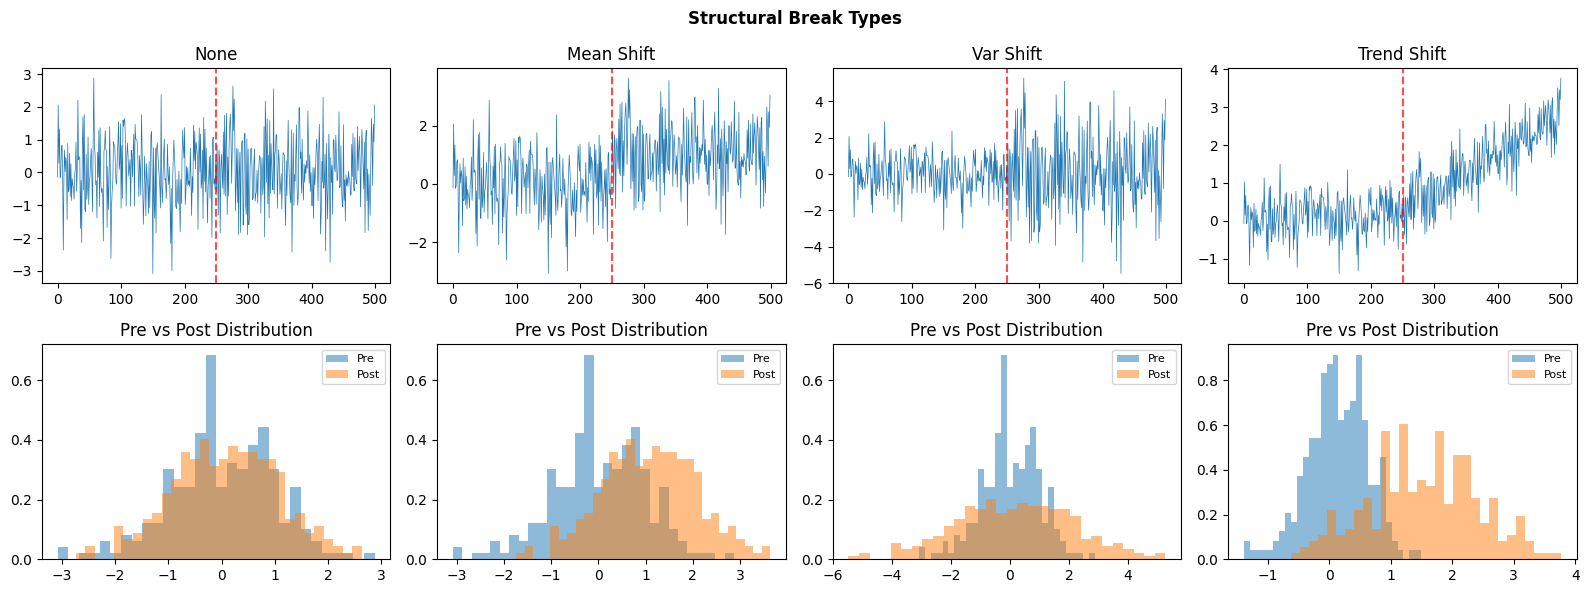

In [13]:
# Visualize examples
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

types = ["none", "mean_shift", "var_shift", "trend_shift"]
for i, bt in enumerate(types):
    s, _, mid = generate_break_series(500, bt, magnitude=1.0, seed=99)
    ax = axes[0, i]
    ax.plot(s, linewidth=0.5)
    ax.axvline(mid, color="red", linestyle="--", alpha=0.7)
    ax.set_title(bt.replace("_", " ").title())

    # Show pre/post distributions
    ax = axes[1, i]
    ax.hist(s[:mid], bins=30, alpha=0.5, density=True, label="Pre")
    ax.hist(s[mid:], bins=30, alpha=0.5, density=True, label="Post")
    ax.legend(fontsize=8)
    ax.set_title("Pre vs Post Distribution")

plt.suptitle("Structural Break Types", fontweight="bold")
plt.tight_layout()
plt.show()

### Feature Family 1: Location Shift

Compare the mean/median of pre-boundary vs post-boundary windows.
The core test is Welch's t-test on absolute values (robust to scale differences).

In [14]:
def location_shift_features(series: np.ndarray, boundary: int) -> dict:
    """Compute location shift features comparing pre/post boundary.

    Based on Alphabot features f01-f02: Welch t-test on absolute values
    at multiple window sizes, with Fisher aggregation.
    """
    features = {}
    pre = series[:boundary]
    post = series[boundary:]

    # Welch t-test on raw values
    t_stat, p_val = stats.ttest_ind(pre, post, equal_var=False)
    features["welch_t_pval"] = p_val
    features["welch_t_stat"] = abs(t_stat)

    # Welch t-test on absolute values (captures scale + location shifts)
    for window in [50, 100, 250]:
        w = min(window, len(pre), len(post))
        if w < 10:
            features[f"local_t_abs_{window}"] = 0.5
            continue
        pre_w = np.abs(pre[-w:])
        post_w = np.abs(post[:w])
        _, p = stats.ttest_ind(pre_w, post_w, equal_var=False)
        features[f"local_t_abs_{window}"] = p

    # Fisher aggregation across window sizes (Alphabot f02)
    p_values = [features.get(f"local_t_abs_{w}", 0.5) for w in [50, 100]]
    p_values = [max(p, 1e-300) for p in p_values]  # Avoid log(0)
    fisher_stat = -2 * sum(np.log(p) for p in p_values)
    features["fisher_location"] = 1 - stats.chi2.cdf(fisher_stat, df=2 * len(p_values))

    # Mean difference (standardized)
    pooled_std = np.sqrt((pre.var() + post.var()) / 2)
    if pooled_std > 0:
        features["mean_diff_std"] = abs(pre.mean() - post.mean()) / pooled_std
    else:
        features["mean_diff_std"] = 0.0

    return features

### Feature Family 2: Scale Shift

Detect changes in variance/dispersion using F-test, Levene, and Fligner-Killeen.

In [15]:
def scale_shift_features(series: np.ndarray, boundary: int) -> dict:
    """Compute scale shift features: variance ratio, Levene, Fligner-Killeen."""
    features = {}
    pre = series[:boundary]
    post = series[boundary:]

    # F-test variance ratio
    var_ratio = post.var(ddof=1) / max(pre.var(ddof=1), 1e-10)
    features["var_ratio"] = var_ratio
    features["log_var_ratio"] = abs(np.log(max(var_ratio, 1e-10)))

    # F-test p-value (Alphabot f09)
    f_stat = max(var_ratio, 1.0 / max(var_ratio, 1e-10))
    df1 = len(post) - 1
    df2 = len(pre) - 1
    f_pval = 2 * (1 - stats.f.cdf(f_stat, df1, df2))
    features["f_test_pval"] = f_pval
    features["neg_log10_f_pval"] = -np.log10(max(f_pval, 1e-300))

    # Fligner-Killeen test (robust to non-normality, Alphabot f05)
    _, fk_pval = stats.fligner(pre, post)
    features["fligner_pval"] = fk_pval

    # Levene test
    _, levene_pval = stats.levene(pre, post)
    features["levene_pval"] = levene_pval

    return features

### Feature Family 3: Distribution Shift

Detect full distributional changes using KS test, JSD, Hellinger distance,
and Wasserstein distance. These capture shifts that go beyond mean/variance.

In [16]:
def distribution_shift_features(series: np.ndarray, boundary: int, n_bins: int = 50) -> dict:
    """Compute distribution shift features: KS, JSD, Hellinger, Wasserstein."""
    features = {}
    pre = series[:boundary]
    post = series[boundary:]

    # Kolmogorov-Smirnov test
    ks_stat, ks_pval = stats.ks_2samp(pre, post)
    features["ks_stat"] = ks_stat
    features["ks_pval"] = ks_pval

    # Jensen-Shannon divergence (Alphabot f08)
    # Histogram-based
    all_data = np.concatenate([pre, post])
    bins = np.linspace(all_data.min() - 0.1, all_data.max() + 0.1, n_bins + 1)
    pre_hist, _ = np.histogram(pre, bins=bins, density=True)
    post_hist, _ = np.histogram(post, bins=bins, density=True)
    # Add small epsilon to avoid zeros
    pre_hist = pre_hist + 1e-10
    post_hist = post_hist + 1e-10
    pre_hist = pre_hist / pre_hist.sum()
    post_hist = post_hist / post_hist.sum()
    features["jsd"] = jensenshannon(pre_hist, post_hist) ** 2  # Squared JSD

    # Hellinger distance (Alphabot f11)
    hellinger = np.sqrt(1 - np.sum(np.sqrt(pre_hist * post_hist)))
    features["hellinger"] = hellinger

    # Wasserstein distance (Earth mover's distance)
    features["wasserstein"] = stats.wasserstein_distance(pre, post)

    return features

### Feature Family 4: Dependence Shift

Detect changes in autocorrelation structure. Structural breaks often alter
the temporal dependence pattern (e.g., volatility clustering appears/disappears).

In [17]:
def dependence_shift_features(series: np.ndarray, boundary: int) -> dict:
    """Compute dependence shift features: autocorrelation change, BDS proxy."""
    features = {}
    pre = series[:boundary]
    post = series[boundary:]

    # Lag-1 autocorrelation difference
    if len(pre) > 2 and len(post) > 2:
        ac_pre = np.corrcoef(pre[:-1], pre[1:])[0, 1]
        ac_post = np.corrcoef(post[:-1], post[1:])[0, 1]
        features["autocorr_diff"] = abs(ac_post - ac_pre)
        features["autocorr_pre"] = ac_pre
        features["autocorr_post"] = ac_post
    else:
        features["autocorr_diff"] = 0.0
        features["autocorr_pre"] = 0.0
        features["autocorr_post"] = 0.0

    # Variance of squared values (proxy for volatility clustering change)
    sq_pre = pre**2
    sq_post = post**2
    if len(sq_pre) > 2 and len(sq_post) > 2:
        ac_sq_pre = np.corrcoef(sq_pre[:-1], sq_pre[1:])[0, 1]
        ac_sq_post = np.corrcoef(sq_post[:-1], sq_post[1:])[0, 1]
        features["sq_autocorr_diff"] = abs(ac_sq_post - ac_sq_pre)
    else:
        features["sq_autocorr_diff"] = 0.0

    return features

### Feature Family 5: Change Point Alignment

Use data-driven change point detection (CUSUM) and measure how well
the estimated break aligns with the candidate boundary.

In [18]:
def alignment_features(series: np.ndarray, boundary: int) -> dict:
    """Compute change point alignment features (Alphabot f03)."""
    features = {}
    n = len(series)

    # CUSUM-based change point
    cusum = np.cumsum(series - series.mean())
    cusum_cp = np.argmax(np.abs(cusum))
    features["cusum_dist_to_boundary"] = abs(cusum_cp - boundary) / n
    features["cusum_max"] = abs(cusum[cusum_cp]) / (series.std() * np.sqrt(n))

    # Ruptures Pelt change point — Pelt/optimization can occasionally fail on
    # short, near-constant series; fall back to "no detected break" (distance=1).
    try:
        algo = rpt.Pelt(model="l2", min_size=20).fit(series)
        bkps = algo.predict(pen=np.log(n) * series.var())
        bkps = [b for b in bkps if b < n]
        if bkps:
            closest = min(bkps, key=lambda b: abs(b - boundary))
            features["ruptures_dist_to_boundary"] = abs(closest - boundary) / n
        else:
            features["ruptures_dist_to_boundary"] = 1.0
    except (ValueError, RuntimeError):
        features["ruptures_dist_to_boundary"] = 1.0

    return features

### Combine All Features

Build the full feature matrix from all families and demonstrate classification.

In [19]:
def compute_all_break_features(series: np.ndarray, boundary: int) -> dict:
    """Compute all structural break features for a single series."""
    features = {}
    features.update(location_shift_features(series, boundary))
    features.update(scale_shift_features(series, boundary))
    features.update(distribution_shift_features(series, boundary))
    features.update(dependence_shift_features(series, boundary))
    features.update(alignment_features(series, boundary))
    return features


# Build feature matrix
feature_rows = []
for i, series in enumerate(series_list):
    mid = len(series) // 2
    feat = compute_all_break_features(series, mid)
    feature_rows.append(feat)

X = pd.DataFrame(feature_rows)
y = labels

print(f"Feature matrix: {X.shape}")
print(f"Features: {list(X.columns)}")
X.head()

Feature matrix: (200, 25)
Features: ['welch_t_pval', 'welch_t_stat', 'local_t_abs_50', 'local_t_abs_100', 'local_t_abs_250', 'fisher_location', 'mean_diff_std', 'var_ratio', 'log_var_ratio', 'f_test_pval', 'neg_log10_f_pval', 'fligner_pval', 'levene_pval', 'ks_stat', 'ks_pval', 'jsd', 'hellinger', 'wasserstein', 'autocorr_diff', 'autocorr_pre', 'autocorr_post', 'sq_autocorr_diff', 'cusum_dist_to_boundary', 'cusum_max', 'ruptures_dist_to_boundary']


,welch_t_pval,welch_t_stat,local_t_abs_50,local_t_abs_100,local_t_abs_250,fisher_location,mean_diff_std,var_ratio,log_var_ratio,f_test_pval,...,jsd,hellinger,wasserstein,autocorr_diff,autocorr_pre,autocorr_post,sq_autocorr_diff,cusum_dist_to_boundary,cusum_max,ruptures_dist_to_boundary
0,0.201326,1.279475,0.416761,0.985008,0.610719,0.776012,0.114669,1.001686,0.001684,0.989408,...,0.060058,0.272148,0.120947,0.075067,0.024819,-0.050248,0.038033,0.206,1.090416,0.24
1,0.605470,0.516880,0.054519,0.496558,0.329375,0.124781,0.046324,1.154506,0.143672,0.257664,...,0.064257,0.271257,0.085307,0.069020,-0.057301,0.011718,0.038251,0.168,0.562012,1.00
2,0.926068,0.092840,0.926261,0.700895,0.566752,0.929669,0.008321,0.890318,0.116177,0.359958,...,0.045403,0.233663,0.066475,0.133863,-0.096652,0.037211,0.097279,0.140,0.778003,0.14
3,0.610669,0.509441,0.371451,0.123884,0.359172,0.187691,0.045657,1.093386,0.089279,0.481696,...,0.068597,0.277296,0.087068,0.075128,0.055232,-0.019896,0.050688,0.110,0.782825,0.08
4,0.536910,0.617921,0.401085,0.886064,0.430847,0.723052,0.055379,0.928366,0.074329,0.558014,...,0.063043,0.277041,0.101041,0.060365,0.011366,-0.048999,0.010392,0.150,0.636393,0.07


### Classification with Gradient Boosting

Following the ADIA Lab winners, we use LightGBM to combine the statistical
features. The 2nd-place solution generated 2,408 features from time series
transformations (z-score, cumsum, ranking, moving average/std) and used
SHAP-based selection to pick the top 200–500.

In [20]:
# Handle any NaN/inf values
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Cross-validated AUC
clf = LGBMClassifier(n_estimators=100, max_depth=3, random_state=42, verbose=-1)
cv_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")

print("=== Structural Break Classification ===")
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit on full data for feature importance
clf.fit(X, y)
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("\nTop 10 Features by Importance:")
for feat, imp in importances.head(10).items():
    print(f"  {feat:<30} {imp:.4f}")

=== Structural Break Classification ===
5-Fold CV AUC: 0.9975 (+/- 0.0032)

Top 10 Features by Importance:
  local_t_abs_250                125.0000
  autocorr_post                  100.0000
  welch_t_pval                   50.0000
  fisher_location                50.0000
  local_t_abs_100                43.0000
  wasserstein                    31.0000
  welch_t_stat                   20.0000
  autocorr_pre                   17.0000
  ruptures_dist_to_boundary      14.0000
  var_ratio                      10.0000


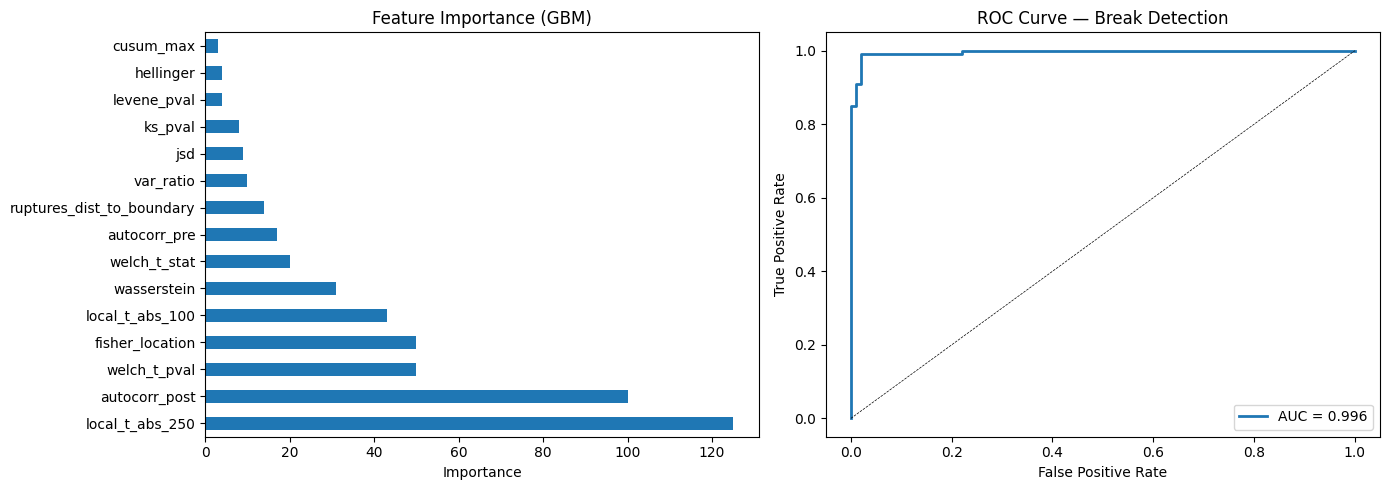

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
ax = axes[0]
importances.head(15).plot.barh(ax=ax)
ax.set_title("Feature Importance (GBM)")
ax.set_xlabel("Importance")

# ROC curve via cross-validation predictions
y_prob = cross_val_predict(clf, X, y, cv=5, method="predict_proba")[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
ax = axes[1]
ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc_score(y, y_prob):.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Break Detection")
ax.legend()

plt.tight_layout()
plt.show()

### Feature Family Contribution Analysis

Which family of features contributes most to break detection?

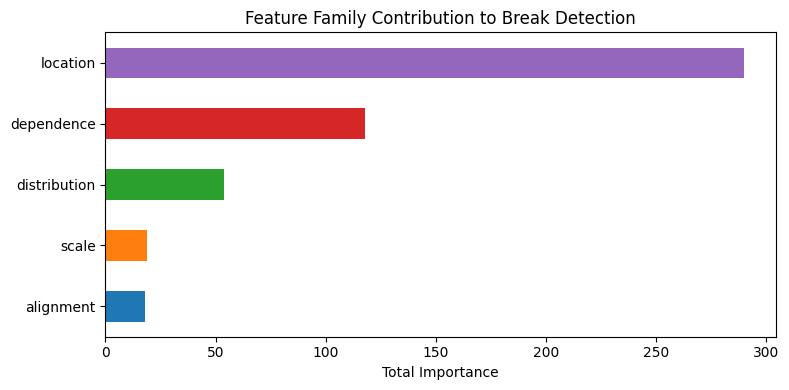

In [22]:
family_map = {
    "location": [
        "welch_t_pval",
        "welch_t_stat",
        "local_t_abs_50",
        "local_t_abs_100",
        "local_t_abs_250",
        "fisher_location",
        "mean_diff_std",
    ],
    "scale": [
        "var_ratio",
        "log_var_ratio",
        "f_test_pval",
        "neg_log10_f_pval",
        "fligner_pval",
        "levene_pval",
    ],
    "distribution": ["ks_stat", "ks_pval", "jsd", "hellinger", "wasserstein"],
    "dependence": ["autocorr_diff", "autocorr_pre", "autocorr_post", "sq_autocorr_diff"],
    "alignment": ["cusum_dist_to_boundary", "cusum_max", "ruptures_dist_to_boundary"],
}

family_importance = {}
for family, feats in family_map.items():
    existing = [f for f in feats if f in importances.index]
    family_importance[family] = importances[existing].sum()

family_series = pd.Series(family_importance).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
family_series.plot.barh(ax=ax, color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
ax.set_title("Feature Family Contribution to Break Detection")
ax.set_xlabel("Total Importance")
plt.tight_layout()
plt.show()

## Application to Financial Data

Apply the break classification features to SPY returns around known
crisis periods to test whether the statistical features detect
genuine structural breaks.

In [23]:
def analyze_period(
    returns: pd.Series, center_date: str, window: int = 250, label: str = ""
) -> dict[str, Any] | None:
    """Compute break features around a specific date."""
    center = pd.Timestamp(center_date)
    mask = (returns.index >= center - pd.Timedelta(days=window * 2)) & (
        returns.index <= center + pd.Timedelta(days=window * 2)
    )
    period_returns = returns[mask].dropna().values

    if len(period_returns) < 100:
        return None

    mid = len(period_returns) // 2
    features = compute_all_break_features(period_returns, mid)
    features["period"] = label
    features["center_date"] = center_date
    features["n_obs"] = len(period_returns)
    return features


spy_returns = spy_pd["returns"].dropna()

periods = [
    ("2008-09-15", "2008 Financial Crisis"),
    ("2020-03-11", "COVID-19 Crash"),
    ("2011-08-05", "US Debt Downgrade"),
    ("2015-06-15", "Mid-2015 (Quiet)"),
    ("2017-06-15", "Mid-2017 (Quiet)"),
    ("2019-06-15", "Mid-2019 (Quiet)"),
]

period_results = []
for date, label in periods:
    result = analyze_period(spy_returns, date, label=label)
    if result is not None:
        period_results.append(result)

period_df = pd.DataFrame(period_results)

# Key metrics comparison
key_cols = [
    "period",
    "ks_stat",
    "jsd",
    "wasserstein",
    "mean_diff_std",
    "var_ratio",
    "fisher_location",
]
display(period_df[key_cols])

,period,ks_stat,jsd,wasserstein,mean_diff_std,var_ratio,fisher_location
0,2008 Financial Crisis,0.101449,0.049878,0.714132,0.020231,3.999075,1.110223e-16
1,COVID-19 Crash,0.127907,0.038594,0.258123,0.126821,1.489563,8.915189e-04
2,US Debt Downgrade,0.054796,0.027183,0.141446,0.015692,1.523967,1.483258e-12
3,Mid-2015 (Quiet),0.063584,0.032601,0.170204,0.046706,1.851906,3.175595e-03
4,Mid-2017 (Quiet),0.052023,0.042957,0.085900,0.058540,1.442327,7.743998e-01
5,Mid-2019 (Quiet),0.099992,0.037011,0.400840,0.026321,3.251529,1.140006e-01


,period,break_probability
0,2008 Financial Crisis,0.999979
5,Mid-2019 (Quiet),0.999971
1,COVID-19 Crash,0.999163
3,Mid-2015 (Quiet),0.989057
2,US Debt Downgrade,0.983301
4,Mid-2017 (Quiet),0.000068


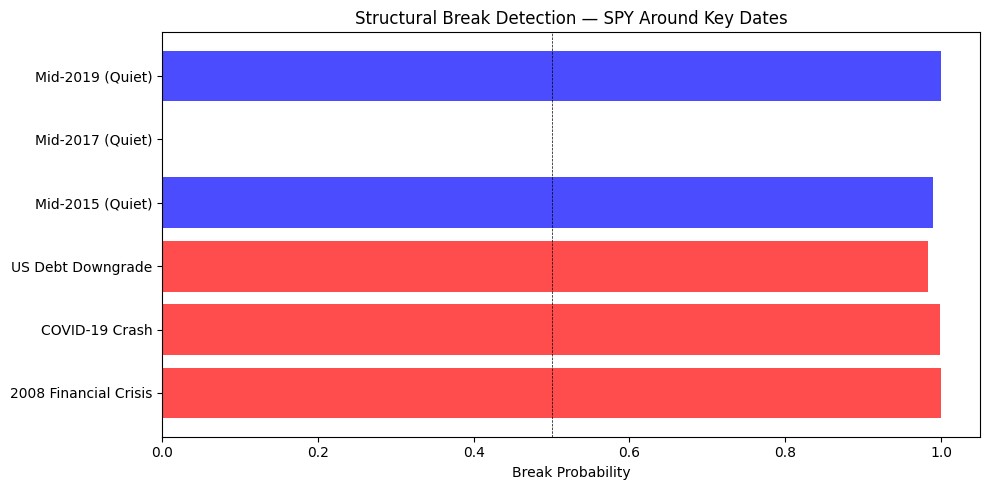

In [24]:
# Predict break probability for each period
period_X = period_df[[c for c in X.columns if c in period_df.columns]]
period_X = period_X.replace([np.inf, -np.inf], np.nan).fillna(0)
period_df["break_probability"] = clf.predict_proba(period_X)[:, 1]

display(
    period_df[["period", "break_probability"]].sort_values("break_probability", ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    "red" if "Crisis" in p or "COVID" in p or "Downgrade" in p else "blue"
    for p in period_df["period"]
]
ax.barh(period_df["period"], period_df["break_probability"], color=colors, alpha=0.7)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.5)
ax.set_xlabel("Break Probability")
ax.set_title("Structural Break Detection — SPY Around Key Dates")
plt.tight_layout()
plt.show()

**Finding**: The classifier returns near-certain break probability on every
crisis period and on two of the three "quiet" periods (mid-2015 and mid-2019).
Only mid-2017 — the one window with no embedded volatility shift — comes back
with a low probability. The lesson is not that the features are useless. They
correctly rank the magnitude of distributional change (compare `wasserstein`
and `var_ratio` across periods in the table above). It is that a classifier
trained on synthetic 500-step windows with magnitude-1 mean/variance shifts
cannot be used as a calibrated detector on 1000-day SPY windows: almost any
real market window contains a shift larger than the training-time threshold.

**Caveat**: For production use, train on historical breaks with labeled
regime changes (e.g., NBER recession dates, central-bank-policy turning points,
or Bai-Perron break dates from a long sample), or use the feature values
directly as continuous inputs to a downstream model rather than relying on the
classifier's probability calibration.

## ml4t-engineer: Break Detection as Polars Expressions

The manual feature engineering above computes statistical tests in NumPy.
`ml4t-engineer` provides rolling break detection features as Polars
expressions — coefficient of variation, KL divergence, Wasserstein
distance, and drift — inspired by the ADIA Lab competition insights.

In [25]:
# Load SPY for ml4t-engineer demonstration
spy_break = (
    etfs.filter(pl.col("symbol") == "SPY")
    .select(["timestamp", "close"])
    .sort("timestamp")
    .with_columns(returns=pl.col("close").pct_change())
    .drop_nulls()
)

# Coefficient of variation (std / |mean|) is only well defined on a
# strictly-positive series: raw daily returns have a near-zero mean, so the
# denominator collapses and CV explodes into the thousands - meaningless as a
# regime gate. Apply it to the *magnitude* of returns instead, where the mean
# is safely positive; CV(|returns|) then reads as the relative variability of
# move size, spiking when the volatility regime itself becomes unstable.
spy_break = spy_break.with_columns(
    cv=coefficient_of_variation(pl.col("returns").abs(), window=50),
    kl_div=rolling_kl_divergence("returns", window=100),
    w_dist=rolling_wasserstein("returns", window=100),
    drift=rolling_drift("returns", window=100),
)

print("=== ml4t-engineer: Break Detection Features ===")
for col in ["cv", "kl_div", "w_dist", "drift"]:
    vals = spy_break[col].drop_nulls()
    print(f"  {col:<10}: mean={vals.mean():.4f}, std={vals.std():.4f}")

=== ml4t-engineer: Break Detection Features ===
  cv        : mean=0.8690, std=0.1338
  kl_div    : mean=2.1192, std=1.4922
  w_dist    : mean=0.0038, std=0.0040
  drift     : mean=-0.0433, std=0.8166


These features can be combined with the CUSUM/MOSUM statistics above
as input to a classifier (Section 5) or used directly as regime change
indicators in downstream ML pipelines.

## Key Takeaways

1. **Classical tests** (Zivot-Andrews, Bai-Perron) detect level/trend breaks
   but are limited to specific null hypotheses
2. **CUSUM/MOSUM** provide online monitoring capability — useful for real-time
   regime change detection
3. **ML-based classification** (ADIA Lab approach) combines multiple
   statistical features into a single classifier; the 5-fold CV AUC of
   0.998 on the synthetic benchmark in this notebook reflects the
   controlled known-break structure, not real-data performance
4. **Five feature families** capture different aspects of distributional change:
   location, scale, distribution shape, dependence structure, and alignment
5. **Fisher aggregation** combines p-values across window sizes for robust
   multi-scale evidence
6. The **2nd-place approach** (2,408 features from time series transformations +
   LightGBM) demonstrates that brute-force feature engineering combined with
   feature selection can rival domain-specific features

**Previous**: `01_visual_diagnostics` for stationarity testing fundamentals.
**Next**: `03_fractional_differencing` for memory-preserving stationarity transforms.